#**Decode Labs | Project 2**

##**BY: Maryam Irfan**

###**Import libraries**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [15]:
# Load iris dataset
iris = load_iris()

# Features
X = iris.data

# Labels
y = iris.target

# Show first 5 rows
print(X[:5])

# Show labels
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [16]:
print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']


##**Data Visualization**

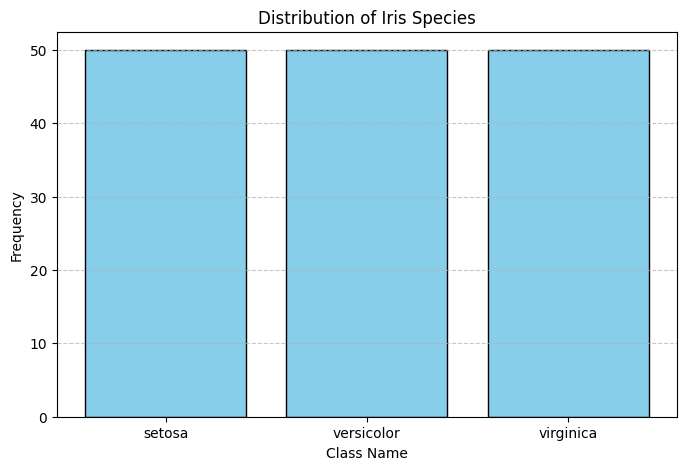

In [18]:
import matplotlib.pyplot as plt

# Create a histogram of the target labels
plt.figure(figsize=(8, 5))
plt.hist(y, bins=np.arange(4) - 0.5, rwidth=0.8, color='skyblue', edgecolor='black')

# Set labels and title
plt.xticks(ticks=[0, 1, 2], labels=iris.target_names)
plt.xlabel('Class Name')
plt.ylabel('Frequency')
plt.title('Distribution of Iris Species')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

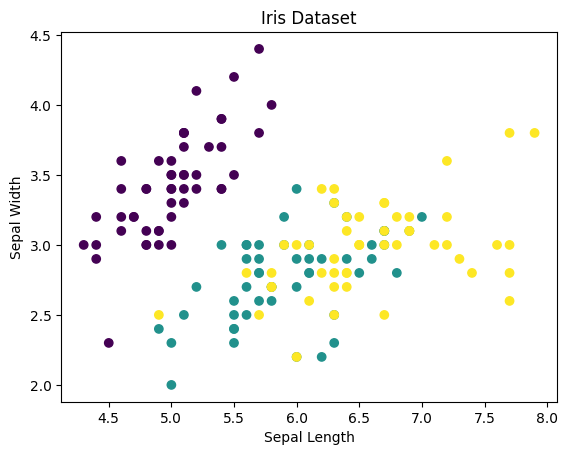

In [19]:
plt.scatter(X[:, 0], X[:, 1], c=y)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.title("Iris Dataset")

plt.show()

##**Split the dataset**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

##**Data Preprocesing (Normalization)**

In [29]:
scaler = StandardScaler()

# Learn scaling from training data
X_train = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test = scaler.transform(X_test)

##**KNN Model**

####**Selecting the Best K value via elbow method**

In [33]:
error_rates = []

for k in range(1, 11):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    error = np.mean(y_pred != y_test)

    error_rates.append(error)

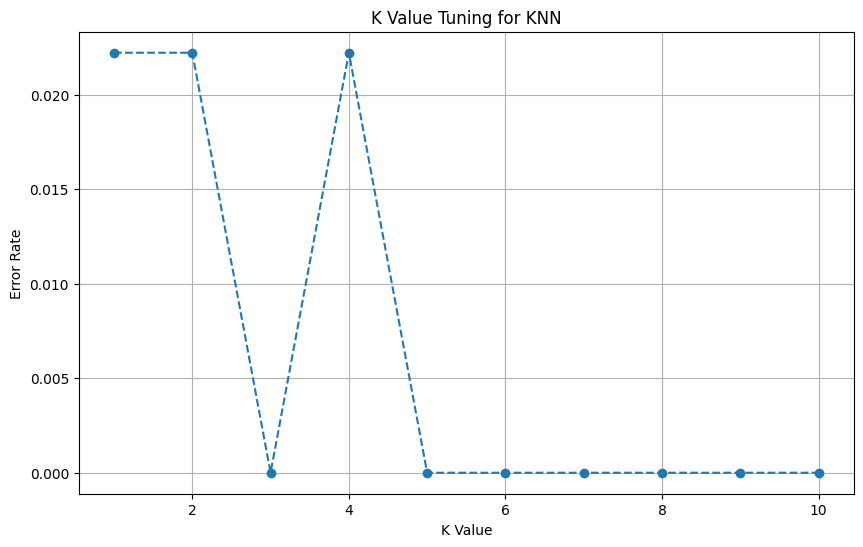

In [35]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1, 11),
    error_rates,
    marker='o',
    linestyle='dashed'
)

plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("K Value Tuning for KNN")

plt.grid(True)

plt.show()

The best K values are the ones with:

Error Rate=0

From the elbow graph:

K = 3
K = 5–10

all achieved perfect classification

I am selecting K-value: K = 5

In [36]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

##**Make Predictions**

In [37]:
y_pred = knn.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


##**Model Evaluation**

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [39]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [40]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn.predict(sample)

print("Predicted Class:", iris.target_names[prediction][0])

Predicted Class: virginica


##**Summary**

This project focused on building a basic supervised machine learning classification system using the K-Nearest Neighbors (KNN) algorithm in Google Colab. The Iris dataset was used to train and evaluate the model for predicting flower species based on features such as sepal length, sepal width, petal length, and petal width.

The project began with loading and understanding the dataset, followed by splitting the data into training and testing sets. Since KNN is a distance-based algorithm, feature normalization was applied using StandardScaler to improve prediction accuracy and prevent features with larger values from dominating distance calculations.

To determine the most suitable K value, a K-value tuning graph (Elbow-style analysis) was implemented by testing multiple neighbor values and comparing their error rates. Based on the analysis, an optimal K value was selected for the final model.

The trained KNN classifier was then evaluated using accuracy score, confusion matrix, and classification report. The model achieved high accuracy on the Iris dataset, demonstrating the effectiveness of supervised learning and nearest-neighbor classification techniques.

Overall, the project provided practical experience in machine learning workflows including data preprocessing, model training, hyperparameter tuning, prediction, and performance evaluation using Python and Scikit-learn.
